In [2]:
import numpy as np

def f(x):
    return x**3 - 9*x + 3

def df(x):
    return 3*x**2 - 9

In [3]:
def bisseccao(f, a, b, tol=1e-6, max_iter=100):
    iteracoes = 0

    if f(a) * f(b) > 0:
        raise ValueError("Intervalo inválido!")

    while (b - a)/2 > tol:
        c = (a + b)/2

        if f(c) == 0:
            break

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

        iteracoes += 1

    return c, iteracoes

In [4]:
def newton(f, df, x0, tol=1e-6, max_iter=100):
    x = x0

    for i in range(max_iter):
        x_new = x - f(x)/df(x)

        if abs(x_new - x) < tol:
            return x_new, i+1

        x = x_new

    return x, max_iter

In [5]:
def secante(f, x0, x1, tol=1e-6, max_iter=100):
    for i in range(max_iter):
        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))

        if abs(x2 - x1) < tol:
            return x2, i+1

        x0, x1 = x1, x2

    return x2, max_iter

In [10]:
raiz_biss, it_biss = bisseccao(f, 0, 1)

raiz_newton, it_newton = newton(f, df, 0.5)

raiz_sec, it_sec = secante(f, 0, 1)

print("Resultados:\n")

print(f"Bissecção -> Raiz: {raiz_biss:.6f} | Iterações: {it_biss}")
print(f"Newton     -> Raiz: {raiz_newton:.6f} | Iterações: {it_newton}")
print(f"Secante    -> Raiz: {raiz_sec:.6f} | Iterações: {it_sec}")

Resultados:

Bissecção -> Raiz: 0.337610 | Iterações: 19
Newton     -> Raiz: 0.337609 | Iterações: 4
Secante    -> Raiz: 0.337609 | Iterações: 5


# Investigação

## Qual método convergiu mais rapidamente?

O método que convergiu mais rapidamente foi o de Newton.

## A secante sempre converge?



In [11]:
pares_iniciais = [
    (0, 1),     # bom
    (1, 2),     # pode convergir
    (-2, 0),    # bom
    (2, 3),     # pode falhar
    (-3, -1),   # pode falhar
    (1, 1.1)    # risco de dar problema
]

print("Testes da SECANTE:\n")

for x0, x1 in pares_iniciais:
    try:
        raiz, it = secante(f, x0, x1)
        print(f"x0={x0}, x1={x1} -> raiz={raiz:.6f}, iter={it}")
    except:
        print(f"x0={x0}, x1={x1} -> FALHOU")

Testes da SECANTE:

x0=0, x1=1 -> raiz=0.337609, iter=5
x0=1, x1=2 -> raiz=0.337609, iter=7
x0=-2, x1=0 -> raiz=0.337609, iter=5
x0=2, x1=3 -> raiz=2.816914, iter=6
x0=-3, x1=-1 -> raiz=-3.154523, iter=9
x0=1, x1=1.1 -> raiz=0.337609, iter=6


Não, pois a secante não garante convergência para qualquer valor inicial. Ela depende dos chutes iniciais e pode divergir ou falhar quando esses valores são inadequados.

## Em quais situações o método da secante pode falhar?

A secante pode falhar quando os chutes iniciais são ruins, quando  f(x1) ≈ f(x0), causando divisão por zero ou quando a função é muito instável.

## Compare a necessidade de informação adicional entre os métodos:

## Bissecção
## Newton
## Secante

A bissecção precisa de intervalo com troca de sinal. Newton precisa da derivada e de um chute. Secante precisa de dois chutes.

## Se você estivesse desenvolvendo um software de engenharia para encontrar raízes de funções desconhecidas, qual método escolheria e por quê?

Eu escolheria o método da secante por ser mais simples de implementar e não exigir o cálculo da derivada.

# Desafio extra

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return x**3 - 9*x + 3

def df(x):
    return 3*x**2 - 9

# Valor "real" da raiz (alta precisão)
raiz_real = 0.337608955965

# -------------------------------
# Bissecção (guardando erros)
# -------------------------------
def bisseccao_erro(f, a, b, tol=1e-10):
    erros = []

    while (b - a)/2 > tol:
        c = (a + b)/2
        erro = abs(c - raiz_real)
        erros.append(erro)

        if f(a)*f(c) < 0:
            b = c
        else:
            a = c

    return erros

# -------------------------------
# Newton (guardando erros)
# -------------------------------
def newton_erro(f, df, x0, tol=1e-10):
    erros = []
    x = x0

    while True:
        x_new = x - f(x)/df(x)
        erro = abs(x_new - raiz_real)
        erros.append(erro)

        if abs(x_new - x) < tol:
            break

        x = x_new

    return erros

# -------------------------------
# Secante (guardando erros)
# -------------------------------
def secante_erro(f, x0, x1, tol=1e-10):
    erros = []

    while True:
        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))
        erro = abs(x2 - raiz_real)
        erros.append(erro)

        if abs(x2 - x1) < tol:
            break

        x0, x1 = x1, x2

    return erros

# Executando
erros_biss = bisseccao_erro(f, 0, 1)
erros_newton = newton_erro(f, df, 0.5)
erros_sec = secante_erro(f, 0, 1)

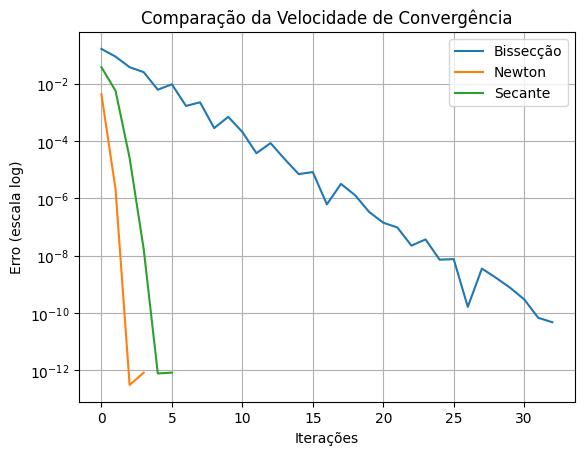

In [14]:
plt.figure()

plt.semilogy(erros_biss, label="Bissecção")
plt.semilogy(erros_newton, label="Newton")
plt.semilogy(erros_sec, label="Secante")

plt.xlabel("Iterações")
plt.ylabel("Erro (escala log)")
plt.title("Comparação da Velocidade de Convergência")

plt.legend()
plt.grid()

plt.show()